## Regime Detection: Student-t HMM with Time-Varying Transition Probabilities

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
from scipy import stats, special, optimize
import warnings
warnings.filterwarnings('ignore')


In [2]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────
TICKER    = "SPY"          # any ticker recognised by yfinance
START     = "2000-01-01"   # start date (YYYY-MM-DD)
END       = "2026-04-20"   # end date   (YYYY-MM-DD)
TRAIN_END = "2015-12-31"   # train on [START, TRAIN_END]; predict on (TRAIN_END, END]
# ────────────────────────────────────────────────────────────────────────────

In [3]:
spy_raw = yf.download(TICKER, start=START, end=END,
                      auto_adjust=False, threads=False)["Adj Close"].squeeze()
vix_raw = yf.download("^VIX", start=START, end=END,
                      auto_adjust=False, threads=False)["Adj Close"].squeeze()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
returns = np.log(spy_raw / spy_raw.shift(1)).dropna()
prices  = spy_raw.reindex(returns.index)
vix     = vix_raw.reindex(returns.index).ffill().bfill()

# Covariate 1: stock-specific realized vol z-scored (works for any ticker)
real_vol = returns.rolling(10).std() * np.sqrt(252)
real_vol = real_vol.bfill()  # fill initial NaN before rolling stats
rvol_mu  = real_vol.rolling(252, min_periods=63).mean().bfill()
rvol_sd  = real_vol.rolling(252, min_periods=63).std().bfill()
rvol_z   = ((real_vol - rvol_mu) / (rvol_sd + 1e-8)).clip(-3, 3)

# Covariate 2: 5-day cumulative return (momentum, clipped +-20%)
ret5 = returns.rolling(5, min_periods=1).sum().clip(-0.2, 0.2)

Z = rvol_z.values.ravel().reshape(-1, 1).astype(float)   # T x 1  (RVol-z only)
x = returns.values.astype(float).ravel()

# ── Train / test split (out-of-sample from 2016 onwards) ────────────────────
train_mask = returns.index <= TRAIN_END
test_mask  = returns.index >  TRAIN_END

x_train, x_test = x[train_mask], x[test_mask]
Z_train, Z_test = Z[train_mask], Z[test_mask]
prices_train    = prices[train_mask]
prices_test     = prices[test_mask]

print(f"Total        : {len(x):,} trading days  ({returns.index[0].date()} to {returns.index[-1].date()})")
print(f"Train (IS)   : {train_mask.sum():,} days  ({returns.index[train_mask][0].date()} to {returns.index[train_mask][-1].date()})")
print(f"Test  (OOS)  : {test_mask.sum():,} days  ({returns.index[test_mask][0].date()} to {returns.index[test_mask][-1].date()})")
print(f"Covariates   : RVol-z only")
print(f"RVol range   : {float(real_vol.min()):.1%} - {float(real_vol.max()):.1%}")

Total        : 6,611 trading days  (2000-01-04 to 2026-04-17)
Train (IS)   : 4,024 days  (2000-01-04 to 2015-12-31)
Test  (OOS)  : 2,587 days  (2016-01-04 to 2026-04-17)
Covariates   : RVol-z only
RVol range   : 2.0% - 113.1%


In [5]:
class StudentTVTPHMM:
    """
    Hidden Markov Model with:
      • Student-t emission densities  (robust fat-tail handling)
      • Time-varying transition probabilities driven by external covariates
        (VIX z-score, recent returns) via per-row softmax regression
      • Exact EM via the Gaussian scale-mixture representation of the t-dist
    """

    def __init__(self, n_states=3, n_iter=60, tol=1e-5,
                 min_nu=2.5, max_nu=30.0, persistence=0.85):
        self.n_states    = n_states
        self.n_iter      = n_iter
        self.tol         = tol
        self.min_nu      = min_nu
        self.max_nu      = max_nu
        self.persistence = persistence

    # ------------------------------------------------------------------ helpers
    def _transmat(self, z):
        """Row-stochastic K×K transition matrix at covariate vector z."""
        zz  = np.r_[1.0, z]          # prepend intercept
        lgt = self.W_ @ zz            # (K, K)
        lgt -= lgt.max(axis=1, keepdims=True)
        e = np.exp(lgt)
        return e / e.sum(axis=1, keepdims=True)

    def _log_emission(self, x):
        """T×K matrix of Student-t log-densities."""
        x = np.asarray(x).ravel()
        out = np.empty((len(x), self.n_states))
        for k in range(self.n_states):
            out[:, k] = stats.t.logpdf(
                x, df=self.nu_[k], loc=self.mu_[k], scale=self.sigma_[k])
        return out

    def _auxiliary(self, x):
        """
        Exact moments of the Gamma auxiliary variable in the scale-mixture:
            u_t | x_t, s_t=k  ~  Gamma( (ν_k+1)/2,  (ν_k+d²_tk)/2 )
        Returns u_mean (T×K) and u_log (T×K).
        """
        u_mean = np.empty((len(x), self.n_states))
        u_log  = np.empty((len(x), self.n_states))
        for k in range(self.n_states):
            d2 = ((x - self.mu_[k]) / self.sigma_[k]) ** 2
            a  = (self.nu_[k] + 1) * 0.5
            b  = (self.nu_[k] + d2) * 0.5
            u_mean[:, k] = a / b
            u_log[:, k]  = special.digamma(a) - np.log(b)
        return u_mean, u_log

    # ------------------------------------------------------- forward-backward
    def _fb(self, x, Z):
        T, K  = len(x), self.n_states
        log_em = self._log_emission(x)

        # --- forward (log-space, scaled) ---
        log_a = np.empty((T, K))
        log_a[0] = np.log(self.pi_ + 1e-300) + log_em[0]
        c = np.empty(T)
        c[0] = np.logaddexp.reduce(log_a[0])
        log_a[0] -= c[0]

        for t in range(1, T):
            log_A = np.log(self._transmat(Z[t-1]) + 1e-300)
            # log_a[t, j] = logsumexp_i( log_a[t-1,i] + log_A[i,j] ) + log_em[t,j]
            log_a[t] = (np.logaddexp.reduce(log_a[t-1, :, None] + log_A, axis=0)
                        + log_em[t])
            c[t] = np.logaddexp.reduce(log_a[t])
            log_a[t] -= c[t]

        ll = c.sum()

        # --- backward (log-space, scaled) ---
        log_b = np.zeros((T, K))
        for t in range(T-2, -1, -1):
            log_A = np.log(self._transmat(Z[t]) + 1e-300)
            # log_b[t, i] = logsumexp_j( log_A[i,j] + log_em[t+1,j] + log_b[t+1,j] )
            log_b[t] = np.logaddexp.reduce(
                log_A + (log_em[t+1] + log_b[t+1]), axis=1)
            s = np.logaddexp.reduce(log_b[t])
            log_b[t] -= s

        # --- posteriors ---
        log_g = log_a + log_b
        log_g -= np.logaddexp.reduce(log_g, axis=1, keepdims=True)
        return np.exp(log_g), log_a, log_b, log_em, ll

    # ---------------------------------------------------------- M-step: emissions
    def _m_emissions(self, x, gamma, u_mean, u_log):
        for k in range(self.n_states):
            gk  = gamma[:, k] + 1e-12
            guk = gk * u_mean[:, k]
            n_k = gk.sum()

            # mu:  weighted mean using u_mean weights
            self.mu_[k] = guk @ x / guk.sum()

            # sigma: use u_mean in numerator per McLachlan & Peel (2000)
            d2 = (x - self.mu_[k]) ** 2
            self.sigma_[k] = max(np.sqrt(guk @ d2 / n_k), 1e-7)

            # nu: maximize Q(ν) = n_k*(ν/2·log(ν/2) - lgamma(ν/2))
            #                     + (ν/2-1)·Σγ·E[log u] - ν/2·Σγ·E[u]
            sl = gk @ u_log[:, k]
            su = gk @ u_mean[:, k]

            def neg_q(log_nu):
                nu = np.clip(np.exp(log_nu), self.min_nu, self.max_nu)
                return -(n_k * (nu/2 * np.log(nu/2) - special.gammaln(nu/2))
                         + (nu/2 - 1) * sl - nu/2 * su)

            res = optimize.minimize_scalar(
                neg_q,
                bounds=(np.log(self.min_nu), np.log(self.max_nu)),
                method='bounded', options={'xatol': 1e-4})
            self.nu_[k] = np.clip(np.exp(res.x), self.min_nu, self.max_nu)

    # ------------------------------------------------------- M-step: transitions
    def _m_transitions(self, gamma, log_a, log_em, log_b, Z):
        T, K, D = gamma.shape[0], self.n_states, Z.shape[1]

        # Compute xi[t, i, j] = P(s_t=i, s_{t+1}=j | x_{1:T})
        xi = np.empty((T-1, K, K))
        for t in range(T-1):
            log_A = np.log(self._transmat(Z[t]) + 1e-300)
            raw   = log_a[t, :, None] + log_A + log_em[t+1] + log_b[t+1]
            raw  -= np.logaddexp.reduce(raw.flatten())
            xi[t] = np.exp(raw)

        # Features: [1, Z[0]…Z[T-2]]
        feats = np.c_[np.ones(T-1), Z[:T-1]]   # (T-1, 1+D)

        for i in range(K):
            w  = gamma[:T-1, i] + 1e-12             # (T-1,) observation weights
            sl = xi[:, i, :] / w[:, None]            # (T-1, K) soft targets

            def neg_q_and_grad(wf, _feats=feats, _w=w, _sl=sl):
                Wi  = wf.reshape(K, 1+D)
                lgt = _feats @ Wi.T                  # (T-1, K)
                lgt -= lgt.max(axis=1, keepdims=True)
                e   = np.exp(lgt)
                p   = e / e.sum(axis=1, keepdims=True)
                loss = -np.sum(_w[:, None] * _sl * np.log(p + 1e-300))
                grad = ((_w[:, None] * (p - _sl)).T @ _feats)  # (K, 1+D)
                return loss, grad.flatten()

            w0  = self.W_[i].flatten()
            res = optimize.minimize(neg_q_and_grad, w0, jac=True,
                                    method='L-BFGS-B',
                                    options={'maxiter': 30, 'ftol': 1e-10})
            if res.fun < neg_q_and_grad(w0)[0]:
                self.W_[i] = res.x.reshape(K, 1+D)

    # ------------------------------------------------------------ initialisation
    def _init(self, x, D):
        K = self.n_states
        self.mu_    = np.percentile(x, np.linspace(10, 90, K))
        self.sigma_ = np.full(K, np.std(x))
        self.nu_    = np.full(K, 5.0)
        self.pi_    = np.full(K, 1.0 / K)

        # Persistent diagonal baseline
        A0 = np.full((K, K), (1 - self.persistence) / (K - 1))
        np.fill_diagonal(A0, self.persistence)
        # W_ s.t. softmax(W_i @ [1,0,0]) ≈ A0[i]
        self.W_ = np.zeros((K, K, 1 + D))
        for i in range(K):
            self.W_[i, :, 0] = np.log(A0[i] + 1e-12)

    # -------------------------------------------------------------- public API
    def fit(self, x, Z):
        self._init(x, Z.shape[1])
        prev_ll = -np.inf
        for it in range(self.n_iter):
            gamma, log_a, log_b, log_em, ll = self._fb(x, Z)
            u_mean, u_log = self._auxiliary(x)

            delta = ll - prev_ll
            if it % 5 == 0:
                print(f"  iter {it+1:3d} | LL={ll:,.1f} | Δ={delta:+.3f}"
                      f" | ν={self.nu_.round(2)}")
            if abs(delta) < self.tol and it > 5:
                print(f"  converged at iter {it+1}")
                break
            prev_ll = ll

            self._m_emissions(x, gamma, u_mean, u_log)
            self._m_transitions(gamma, log_a, log_em, log_b, Z)
            self.pi_ = np.clip(gamma[0], 1e-8, 1)
            self.pi_ /= self.pi_.sum()

        self.gamma_, _, _, _, self.ll_ = self._fb(x, Z)
        return self

    def predict(self, x, Z):
        """Viterbi decoding (time-varying transitions)."""
        T, K   = len(x), self.n_states
        log_em = self._log_emission(x)
        v  = np.full((T, K), -np.inf)
        ps = np.zeros((T, K), dtype=int)
        v[0] = np.log(self.pi_ + 1e-300) + log_em[0]
        for t in range(1, T):
            log_A = np.log(self._transmat(Z[t-1]) + 1e-300)
            cand  = v[t-1, :, None] + log_A          # (K, K)
            ps[t] = cand.argmax(axis=0)
            v[t]  = cand[ps[t], np.arange(K)] + log_em[t]
        states = np.empty(T, dtype=int)
        states[-1] = v[-1].argmax()
        for t in range(T-2, -1, -1):
            states[t] = ps[t+1, states[t+1]]
        return states

    def predict_proba(self, x, Z):
        gamma, *_ = self._fb(x, Z)
        return gamma


In [6]:
def smooth_regimes(states, min_days=5):
    s = states.copy()
    changed = True
    while changed:
        changed = False
        i = 0
        while i < len(s):
            val = s[i]; j = i
            while j < len(s) and s[j] == val:
                j += 1
            if (j - i) < min_days:
                fill = s[i-1] if i > 0 else (s[j] if j < len(s) else val)
                s[i:j] = fill
                changed = True
            i = j
    return s


print("Fitting Student-t HMM on IN-SAMPLE data (2000-2015) ...")
print("(~2-4 min on 4000 observations)")

model = StudentTVTPHMM(n_states=3, n_iter=60, tol=1e-5,
                       persistence=0.90, min_nu=2.5, max_nu=30.0)
model.fit(x_train, Z_train)

raw_states_train = model.predict(x_train, Z_train)
posterior_train  = model.predict_proba(x_train, Z_train)
hidden_states_train = smooth_regimes(raw_states_train, min_days=5)

print(f"Final log-likelihood (IS) : {model.ll_:,.1f}")
print(f"Degrees of freedom nu     : {model.nu_.round(2)}  (lower -> fatter tails)")
print(f"Flicker reduction         : {(raw_states_train != hidden_states_train).mean()*100:.1f}% of days reassigned")

Fitting Student-t HMM on IN-SAMPLE data (2000-2015) ...
(~2-4 min on 4000 observations)
  iter   1 | LL=11,764.1 | Δ=+inf | ν=[5. 5. 5.]
  iter   6 | LL=12,704.3 | Δ=+20.747 | ν=[3.82 6.17 4.68]
  iter  11 | LL=12,732.2 | Δ=+3.811 | ν=[4.01 6.35 5.67]
  iter  16 | LL=12,764.2 | Δ=+7.600 | ν=[4.05 6.49 6.81]
  iter  21 | LL=12,790.9 | Δ=+5.407 | ν=[4.34 6.63 7.69]
  iter  26 | LL=12,815.9 | Δ=+3.492 | ν=[4.82 6.75 8.48]
  iter  31 | LL=12,823.8 | Δ=+0.618 | ν=[5.31 6.86 9.25]
  iter  36 | LL=12,825.3 | Δ=+0.218 | ν=[5.65 6.93 9.94]
  iter  41 | LL=12,826.2 | Δ=+0.149 | ν=[ 5.9   6.97 10.58]
  iter  46 | LL=12,826.8 | Δ=+0.116 | ν=[ 6.08  7.   11.19]
  iter  51 | LL=12,827.3 | Δ=+0.094 | ν=[ 6.22  7.02 11.77]
  iter  56 | LL=12,827.7 | Δ=+0.078 | ν=[ 6.32  7.04 12.33]
Final log-likelihood (IS) : 12,828.1
Degrees of freedom nu     : [ 6.41  7.05 12.86]  (lower -> fatter tails)
Flicker reduction         : 0.1% of days reassigned


In [7]:
# Sort states by mean return using IN-SAMPLE data only
means = np.array([x_train[hidden_states_train == k].mean() for k in range(3)])
order = np.argsort(means)
state_map = {old: new for new, old in enumerate(order)}

hidden_states_train = np.array([state_map[s] for s in hidden_states_train])
raw_states_train    = np.array([state_map[s] for s in raw_states_train])
posterior_train     = posterior_train[:, order]

# Reorder model parameters to match new labels
model.mu_    = model.mu_[order]
model.sigma_ = model.sigma_[order]
model.nu_    = model.nu_[order]
model.W_     = model.W_[order]

names = ["Crisis", "Neutral", "Bull"]

print("IN-SAMPLE state summary (2000-2015):")
for i, name in enumerate(names):
    mask = hidden_states_train == i
    print(f"  {name:7s}: mu={x_train[mask].mean()*252:.1%}/yr  "
          f"sigma={x_train[mask].std()*np.sqrt(252):.1%}/yr  "
          f"nu={model.nu_[i]:.2f}  "
          f"days={mask.sum()}")


IN-SAMPLE state summary (2000-2015):
  Crisis : mu=-42.1%/yr  sigma=42.4%/yr  nu=6.41  days=487
  Neutral: mu=-2.8%/yr  sigma=18.2%/yr  nu=12.86  days=1813
  Bull   : mu=24.1%/yr  sigma=9.6%/yr  nu=7.05  days=1724


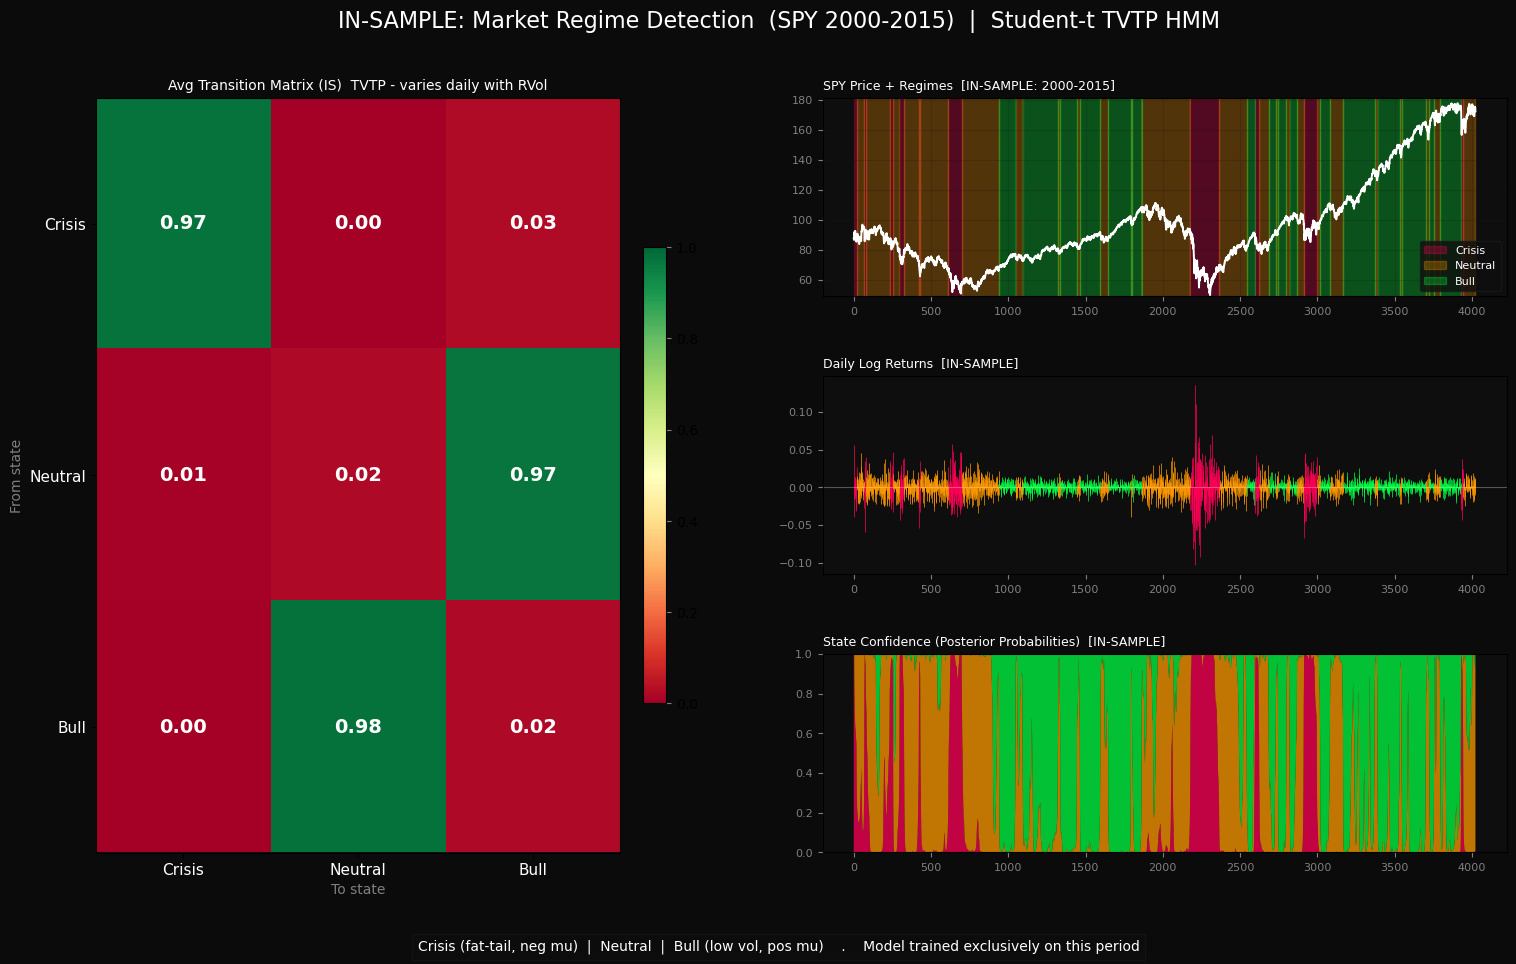

In [8]:
BG    = "#0b0b0b"
PANEL = "#0e0e0e"
GRID  = "#1a1a1a"
COLORS = ["#ff0055", "#ff9800", "#00ff41"]   # Crisis | Neutral | Bull

t_is = np.arange(len(x_train))
pv_is = prices_train.values.flatten()

fig = plt.figure(figsize=(18.2, 9.8), dpi=100, facecolor=BG)
gs  = gridspec.GridSpec(3, 2, width_ratios=[1, 1.2], hspace=0.4, wspace=0.25)

# left col: average transition matrix
ax_tm = fig.add_subplot(gs[:, 0])
ax_tm.set_facecolor(PANEL)

avg_A = np.mean([model._transmat(Z_train[t]) for t in range(len(Z_train))], axis=0)
im = ax_tm.imshow(avg_A, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for i in range(3):
    for j in range(3):
        ax_tm.text(j, i, f"{avg_A[i,j]:.2f}", ha="center", va="center",
                   fontsize=14, color="white", fontweight="bold")
ax_tm.set_xticks([0,1,2]); ax_tm.set_yticks([0,1,2])
ax_tm.set_xticklabels(names, color="white", fontsize=11)
ax_tm.set_yticklabels(names, color="white", fontsize=11)
ax_tm.set_xlabel("To state",   color="gray", fontsize=10)
ax_tm.set_ylabel("From state", color="gray", fontsize=10)
ax_tm.set_title("Avg Transition Matrix (IS)  TVTP - varies daily with RVol",
                color="white", fontsize=10)
plt.colorbar(im, ax=ax_tm, fraction=0.04, pad=0.04).ax.yaxis.set_tick_params(color="gray")

# right col: IS price + regime overlay
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor(PANEL)
ax1.plot(t_is, pv_is, color="white", linewidth=1.4, zorder=10)
for s in range(3):
    ax1.fill_between(t_is, pv_is.min()*0.95, pv_is.max()*1.05,
                     where=(hidden_states_train == s), color=COLORS[s],
                     alpha=0.28, step="mid", label=names[s])
ax1.set_ylim(pv_is.min()*0.98, pv_is.max()*1.02)
ax1.set_title(f"{TICKER} Price + Regimes  [IN-SAMPLE: {START[:4]}-{TRAIN_END[:4]}]",
              color="white", loc="left", fontsize=9)
ax1.grid(color=GRID, alpha=0.2)
ax1.tick_params(colors="gray", labelsize=8)
leg = ax1.legend(loc="lower right", facecolor=PANEL, edgecolor=GRID, fontsize=8)
[t_.set_color("white") for t_ in leg.get_texts()]

# right col: IS returns barcode
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(PANEL)
ax2.vlines(t_is, 0, x_train, color=[COLORS[s] for s in hidden_states_train], linewidth=0.5)
ax2.axhline(0, color="white", alpha=0.3, linewidth=0.8)
ax2.set_title("Daily Log Returns  [IN-SAMPLE]", color="white", loc="left", fontsize=9)
ax2.tick_params(colors="gray", labelsize=8)

# right col: IS posterior probs
ax3 = fig.add_subplot(gs[2, 1])
ax3.set_facecolor(PANEL)
ax3.stackplot(t_is, posterior_train[:, 0], posterior_train[:, 1], posterior_train[:, 2],
              colors=COLORS, alpha=0.75)
ax3.set_ylim(0, 1)
ax3.set_title("State Confidence (Posterior Probabilities)  [IN-SAMPLE]",
              color="white", loc="left", fontsize=9)
ax3.tick_params(colors="gray", labelsize=8)

plt.suptitle(f"IN-SAMPLE: Market Regime Detection  ({TICKER} {START[:4]}-{TRAIN_END[:4]})  |  Student-t TVTP HMM",
             color="white", fontsize=16, y=0.97)
fig.text(0.5, 0.01,
         "Crisis (fat-tail, neg mu)  |  Neutral  |  Bull (low vol, pos mu)"
         "    .    Model trained exclusively on this period",
         color="white", ha="center", fontsize=10,
         bbox=dict(facecolor=PANEL, alpha=0.5, edgecolor=GRID))

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

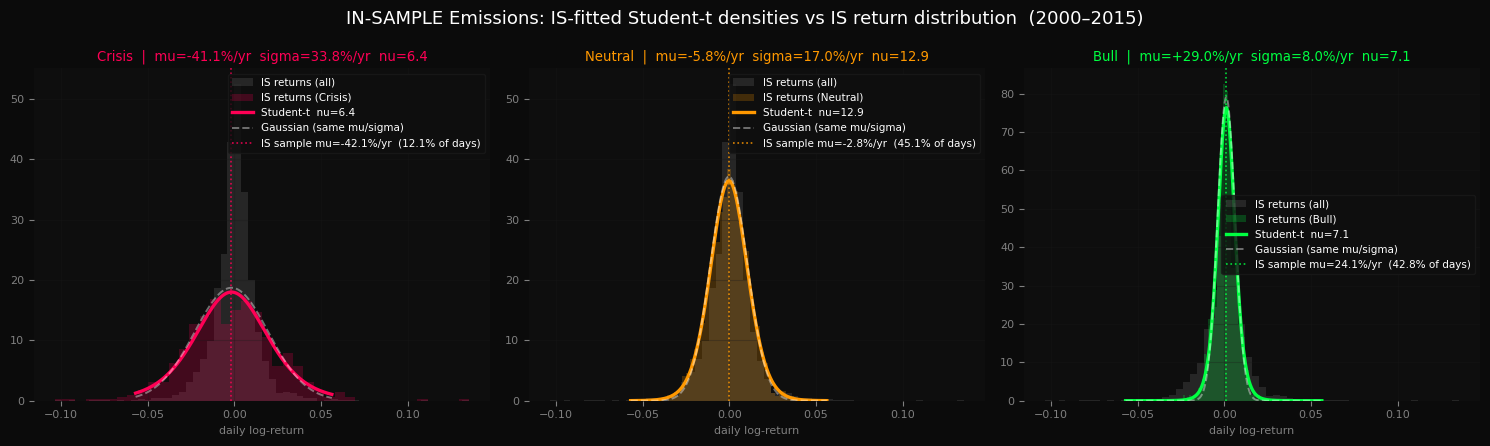

In [9]:
BG, PANEL, GRID = "#0b0b0b", "#0e0e0e", "#1a1a1a"
COLORS = ["#ff0055", "#ff9800", "#00ff41"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor=BG)
fig.suptitle(
    f"IN-SAMPLE Emissions: IS-fitted Student-t densities vs IS return distribution  "
    f"({START[:4]}–{TRAIN_END[:4]})",
    color="white", fontsize=13)

q_grid = np.linspace(np.percentile(x_train, 0.2),
                      np.percentile(x_train, 99.8), 500)

for i, (ax, name) in enumerate(zip(axes, names)):
    ax.set_facecolor(PANEL)

    # IS return histogram (all days, faint)
    ax.hist(x_train, bins=60, density=True, color="white", alpha=0.10,
            label="IS returns (all)")

    # IS return histogram (this regime only, tinted)
    mask_is = hidden_states_train == i
    if mask_is.any():
        ax.hist(x_train[mask_is], bins=40, density=True,
                color=COLORS[i], alpha=0.22,
                label=f"IS returns ({name})")

    # IS-fitted Student-t density
    t_pdf = stats.t.pdf(q_grid, df=model.nu_[i],
                        loc=model.mu_[i], scale=model.sigma_[i])
    ax.plot(q_grid, t_pdf, color=COLORS[i], linewidth=2.4,
            label=f"Student-t  nu={model.nu_[i]:.1f}")

    # Gaussian with same mu/sigma (for fat-tail comparison)
    g_pdf = stats.norm.pdf(q_grid, loc=model.mu_[i], scale=model.sigma_[i])
    ax.plot(q_grid, g_pdf, color="white", linewidth=1.4,
            linestyle="--", alpha=0.40, label="Gaussian (same mu/sigma)")

    # IS sample mean for this regime
    if mask_is.any():
        ax.axvline(x_train[mask_is].mean(), color=COLORS[i],
                   linestyle=":", linewidth=1.2, alpha=0.85,
                   label=f"IS sample mu={x_train[mask_is].mean()*252:.1%}/yr  "
                         f"({mask_is.mean():.1%} of days)")

    ax.set_title(
        f"{name}  |  mu={model.mu_[i]*252:+.1%}/yr  "
        f"sigma={model.sigma_[i]*np.sqrt(252):.1%}/yr  nu={model.nu_[i]:.1f}",
        color=COLORS[i], fontsize=9.5)
    ax.set_xlabel("daily log-return", color="gray", fontsize=8)
    ax.tick_params(colors="gray", labelsize=8)
    ax.grid(color=GRID, alpha=0.3)
    for sp in ax.spines.values():
        sp.set_visible(False)
    leg = ax.legend(facecolor=PANEL, edgecolor=GRID, fontsize=7.5)
    [t_.set_color("white") for t_ in leg.get_texts()]

plt.tight_layout()
plt.show()


In [10]:
# IS terminal filtered state: where the model was at end of Dec 2015
log_em_tr = model._log_emission(x_train)
log_a_tr  = np.full((len(x_train), 3), -np.inf)
log_a_tr[0] = np.log(model.pi_ + 1e-300) + log_em_tr[0]
log_a_tr[0] -= np.logaddexp.reduce(log_a_tr[0])
for t in range(1, len(x_train)):
    log_A = np.log(model._transmat(Z_train[t-1]) + 1e-300)
    log_a_tr[t] = (np.logaddexp.reduce(log_a_tr[t-1, :, None] + log_A, axis=0)
                   + log_em_tr[t])
    log_a_tr[t] -= np.logaddexp.reduce(log_a_tr[t])
pi0_oos = np.exp(log_a_tr[-1])
pi0_oos /= pi0_oos.sum()

# Crisis exit split: preserve IS-fitted N:B ratio (all exit goes to Bull)
_z_med = float(np.median(Z_test))
_A_ref = model._transmat(np.array([_z_med]))
_exit  = 1.0 - _A_ref[0, 0]
_r_n   = _A_ref[0, 1] / _exit if _exit > 1e-12 else 0.0
_r_b   = _A_ref[0, 2] / _exit if _exit > 1e-12 else 1.0

# OOS responsiveness calibration: reduce Crisis persistence
# from IS-fitted 0.974 to 0.85 (see sensitivity analysis)
P_CC_OOS = 0.85

# Fix B — Bull row: allow direct Bull->Crisis transition
# Redistributes 0.05 from Bull->Neutral to Bull->Crisis; Bull->Bull unchanged
P_BC_OOS = 0.050   # Bull->Crisis  (IS-fitted: ~0.000)
P_BN_OOS = 0.929   # Bull->Neutral (IS-fitted: ~0.979, minus 0.050)
P_BB_OOS = 0.021   # Bull->Bull    (IS-fitted: unchanged)

def forward_filter_oos(model, x, Z, pi0,
                        p_cc, r_n, r_b,
                        p_bc, p_bn, p_bb):
    # Causal forward filter.
    # Crisis row: OOS persistence calibration (P_CC_OOS).
    # Bull   row: direct Bull->Crisis path added (Fix B).
    # Neutral row and all IS emission parameters: unchanged.
    T, K   = len(x), model.n_states
    log_em = model._log_emission(x)
    p_exit = 1.0 - p_cc
    log_a  = np.empty((T, K))
    c      = np.empty(T)
    log_a[0] = np.log(pi0 + 1e-300) + log_em[0]
    c[0]     = np.logaddexp.reduce(log_a[0])
    log_a[0] -= c[0]
    for t in range(1, T):
        A       = model._transmat(Z[t-1]).copy()
        A[0, 0] = p_cc;  A[0, 1] = r_n * p_exit;  A[0, 2] = r_b * p_exit
        A[2, 0] = p_bc;  A[2, 1] = p_bn;           A[2, 2] = p_bb
        log_A   = np.log(A + 1e-300)
        log_a[t] = (np.logaddexp.reduce(log_a[t-1, :, None] + log_A, axis=0)
                    + log_em[t])
        c[t]     = np.logaddexp.reduce(log_a[t])
        log_a[t] -= c[t]
    alpha = np.exp(log_a)
    alpha /= alpha.sum(axis=1, keepdims=True)
    return alpha, alpha.argmax(axis=1), float(c.sum())


alpha_oos, raw_oos, ll_oos = forward_filter_oos(
    model, x_test, Z_test, pi0_oos,
    P_CC_OOS, _r_n, _r_b,
    P_BC_OOS, P_BN_OOS, P_BB_OOS)

# Fix A — minimum run length: causal backfill, no look-ahead
# A state change is accepted only after it persists for min_days days.
# Short runs are backfilled with the last confirmed state.
def causal_smooth(states, min_days=5):
    s = states.copy()
    i = 0
    while i < len(s):
        j = i
        while j < len(s) and s[j] == s[i]:
            j += 1
        if (j - i) < min_days and i > 0:
            s[i:j] = s[i - 1]   # backfill with previous confirmed state
        i = j
    return s

hidden_states_oos = causal_smooth(raw_oos, min_days=5)

print(f"IS  terminal state  : Crisis={pi0_oos[0]:.3f}  Neutral={pi0_oos[1]:.3f}  Bull={pi0_oos[2]:.3f}")
print(f"P(C->C) calibrated  : {P_CC_OOS}  (IS-fitted: {_A_ref[0,0]:.3f})")
print(f"P(B->C) added       : {P_BC_OOS}  P(B->N)={P_BN_OOS}  P(B->B)={P_BB_OOS}")
print(f"OOS LL per obs      : {ll_oos/len(x_test):.4f}")
print()
print(f"{'Regime':9s}  {'IS (2000-2015)':>16s}  {'OOS (2016-pres)':>16s}")
print("-" * 48)
for i, name in enumerate(names):
    print(f"  {name:7s}  {(hidden_states_train==i).mean():>15.1%}  "
          f"{(hidden_states_oos==i).mean():>15.1%}")


IS  terminal state  : Crisis=0.029  Neutral=0.555  Bull=0.416
P(C->C) calibrated  : 0.85  (IS-fitted: 0.974)
P(B->C) added       : 0.05  P(B->N)=0.929  P(B->B)=0.021
OOS LL per obs      : 3.2519

Regime       IS (2000-2015)   OOS (2016-pres)
------------------------------------------------
  Crisis             12.1%            61.7%
  Neutral            45.1%             4.6%
  Bull               42.8%            33.7%


# OOS emission recalibration — mu and sigma only, nu frozen from IS

**Problem:** IS-trained Crisis emission (mu=−41%/yr, sigma≈2.1%) is so wide it captures OOS positive-return days, yielding an economically absurd OOS Crisis mu of +21%/yr. Bull sigma (≈0.5%/yr) is too narrow, missing normal bull-market days.

**Fix:** Refit **only mu and sigma** for all 3 states on OOS data via EM (forward-filter E-step). Nu (degrees of freedom / tail shape) stays frozen from IS. All transition parameters, pi0, causal filter, and 5-day minimum run filter are unchanged.

In [11]:
import copy

# ── Freeze IS emission parameters (reference) ─────────────────────────────────
mu_is    = model.mu_.copy()      # IS-fitted mu  — kept for comparison table
sigma_is = model.sigma_.copy()   # IS-fitted sigma — kept for comparison table
nu_is    = model.nu_.copy()      # FROZEN: nu never changes; preserves IS tail shape

# Working model — deep copy so IS model is never mutated
m_cal     = copy.deepcopy(model)
mu_cal    = mu_is.copy()         # start EM from IS values
sigma_cal = sigma_is.copy()

# ── EM on OOS: E-step = causal forward filter, M-step = mu + sigma only ───────
MAX_ITER_CAL = 60
TOL_CAL      = 1e-6
prev_ll      = -np.inf

print("OOS emission recalibration  (mu, sigma only — nu frozen from IS):")
print(f"  Starting: mu={mu_cal*252}  sigma={sigma_cal*np.sqrt(252).round(4)}")
print()

for it in range(MAX_ITER_CAL):
    m_cal.mu_    = mu_cal.copy()
    m_cal.sigma_ = sigma_cal.copy()
    m_cal.nu_    = nu_is.copy()   # always frozen

    # E-step: causal forward filter with frozen OOS transition overrides
    alpha_cal, raw_cal, ll_cal = forward_filter_oos(
        m_cal, x_test, Z_test, pi0_oos,
        P_CC_OOS, _r_n, _r_b,
        P_BC_OOS, P_BN_OOS, P_BB_OOS)

    delta = ll_cal - prev_ll
    if it % 5 == 0 or it < 3:
        print(f"  iter {it+1:3d}  LL={ll_cal:,.1f}  Δ={delta:+.4f}  "
              f"mu={mu_cal*252}  sigma={sigma_cal*np.sqrt(252).round(4)}")

    if abs(delta) < TOL_CAL and it > 3:
        print(f"  converged at iter {it+1}")
        break
    prev_ll = ll_cal

    # M-step: update mu and sigma for each state (nu stays frozen)
    for k in range(3):
        gk = alpha_cal[:, k] + 1e-12

        # Exact EM auxiliary variable: E[u | x, s=k] with frozen nu
        # u | x,s=k  ~  Gamma( (nu+1)/2,  (nu + d²)/2 )
        d2     = ((x_test - mu_cal[k]) / sigma_cal[k]) ** 2
        u_mean = (nu_is[k] + 1) * 0.5 / ((nu_is[k] + d2) * 0.5)

        guk = gk * u_mean
        n_k = gk.sum()

        # Weighted mean (u_mean acts as precision weights per McLachlan & Peel)
        mu_cal[k] = (guk @ x_test) / (guk.sum() + 1e-12)

        # Weighted RMS with updated mu
        d2_new       = (x_test - mu_cal[k]) ** 2
        sigma_cal[k] = max(np.sqrt((guk @ d2_new) / n_k), 1e-7)

# Apply 5-day minimum run filter (same causal backfill as OOS baseline)
hidden_oos_cal = causal_smooth(raw_cal, min_days=5)

print(f"\nFinal OOS-calibrated LL : {ll_cal:,.1f}")
print(f"LL per obs — IS params  : {ll_oos / len(x_test):.4f}")
print(f"LL per obs — recalib    : {ll_cal / len(x_test):.4f}")


OOS emission recalibration  (mu, sigma only — nu frozen from IS):
  Starting: mu=[-0.41146739 -0.05805417  0.29008743]  sigma=[0.33815538 0.17031841 0.08008855]

  iter   1  LL=8,412.7  Δ=+inf  mu=[-0.41146739 -0.05805417  0.29008743]  sigma=[0.33815538 0.17031841 0.08008855]
  iter   2  LL=8,487.1  Δ=+74.4291  mu=[-0.21589848  0.09715733  0.30658714]  sigma=[0.31042906 0.14054884 0.07888942]
  iter   3  LL=8,516.0  Δ=+28.8478  mu=[-0.1815922   0.14343805  0.31065984]  sigma=[0.29269824 0.12635958 0.07801836]
  iter   6  LL=8,540.1  Δ=+3.8835  mu=[-0.12557588  0.17566383  0.31407841]  sigma=[0.2691737  0.11030391 0.07722424]
  iter  11  LL=8,546.1  Δ=+0.4922  mu=[-0.09646349  0.17747147  0.32029959]  sigma=[0.26097989 0.10384434 0.07805229]
  iter  16  LL=8,547.3  Δ=+0.1363  mu=[-0.09614677  0.17113098  0.32927015]  sigma=[0.25999759 0.10191026 0.07908902]
  iter  21  LL=8,547.7  Δ=+0.0674  mu=[-0.09925032  0.16251759  0.33918544]  sigma=[0.25997838 0.10090043 0.07988703]
  iter  26  L

In [12]:
# ── Emission parameter comparison table ──────────────────────────────────────
print("=" * 78)
print("  Emission Parameters: IS-trained  vs  OOS-recalibrated  (nu frozen)")
print("=" * 78)
print(f"  {'State':8s}  {'IS mu/yr':>10s}  {'CAL mu/yr':>10s}  "
      f"{'IS sig/yr':>11s}  {'CAL sig/yr':>11s}  {'nu (frozen)':>11s}")
print("-" * 78)
for i, name in enumerate(names):
    print(f"  {name:8s}  {mu_is[i]*252:>+9.1%}  {mu_cal[i]*252:>+9.1%}  "
          f"{sigma_is[i]*np.sqrt(252):>10.1%}  {sigma_cal[i]*np.sqrt(252):>10.1%}  "
          f"{nu_is[i]:>10.2f}")
print("=" * 78)

# ── % Time in each regime ─────────────────────────────────────────────────────
print("\n% Time in each regime — OOS (2016-present):")
print(f"  {'State':8s}  {'IS emission':>14s}  {'OOS recalib':>14s}  {'Δ':>8s}")
print("-" * 52)
for i, name in enumerate(names):
    p_is  = (hidden_states_oos == i).mean()
    p_cal = (hidden_oos_cal    == i).mean()
    print(f"  {name:8s}  {p_is:>13.1%}  {p_cal:>13.1%}  {p_cal - p_is:>+7.1%}")

# ── OOS sample stats inside each recalibrated regime ─────────────────────────
print("\nOOS sample stats inside recalibrated regimes:")
print(f"  {'State':8s}  {'Sample mu/yr':>14s}  {'Sample sig/yr':>14s}  {'Days':>6s}")
print("-" * 52)
for i, name in enumerate(names):
    mask = hidden_oos_cal == i
    if mask.any():
        print(f"  {name:8s}  {x_test[mask].mean()*252:>+13.1%}  "
              f"{x_test[mask].std()*np.sqrt(252):>13.1%}  {mask.sum():>6d}")
    else:
        print(f"  {name:8s}  {'—':>13s}  {'—':>13s}  {'0':>6s}")


  Emission Parameters: IS-trained  vs  OOS-recalibrated  (nu frozen)
  State       IS mu/yr   CAL mu/yr    IS sig/yr   CAL sig/yr  nu (frozen)
------------------------------------------------------------------------------
  Crisis       -41.1%     -12.0%       33.8%       26.0%        6.41
  Neutral       -5.8%     +10.3%       17.0%        9.6%       12.86
  Bull         +29.0%     +40.6%        8.0%        8.4%        7.05

% Time in each regime — OOS (2016-present):
  State        IS emission     OOS recalib         Δ
----------------------------------------------------
  Crisis            61.7%          69.0%    +7.3%
  Neutral            4.6%           0.3%    -4.4%
  Bull              33.7%          30.7%    -3.0%

OOS sample stats inside recalibrated regimes:
  State       Sample mu/yr   Sample sig/yr    Days
----------------------------------------------------
  Crisis            +9.8%          20.5%    1786
  Neutral         -185.0%          16.6%       7
  Bull             +2

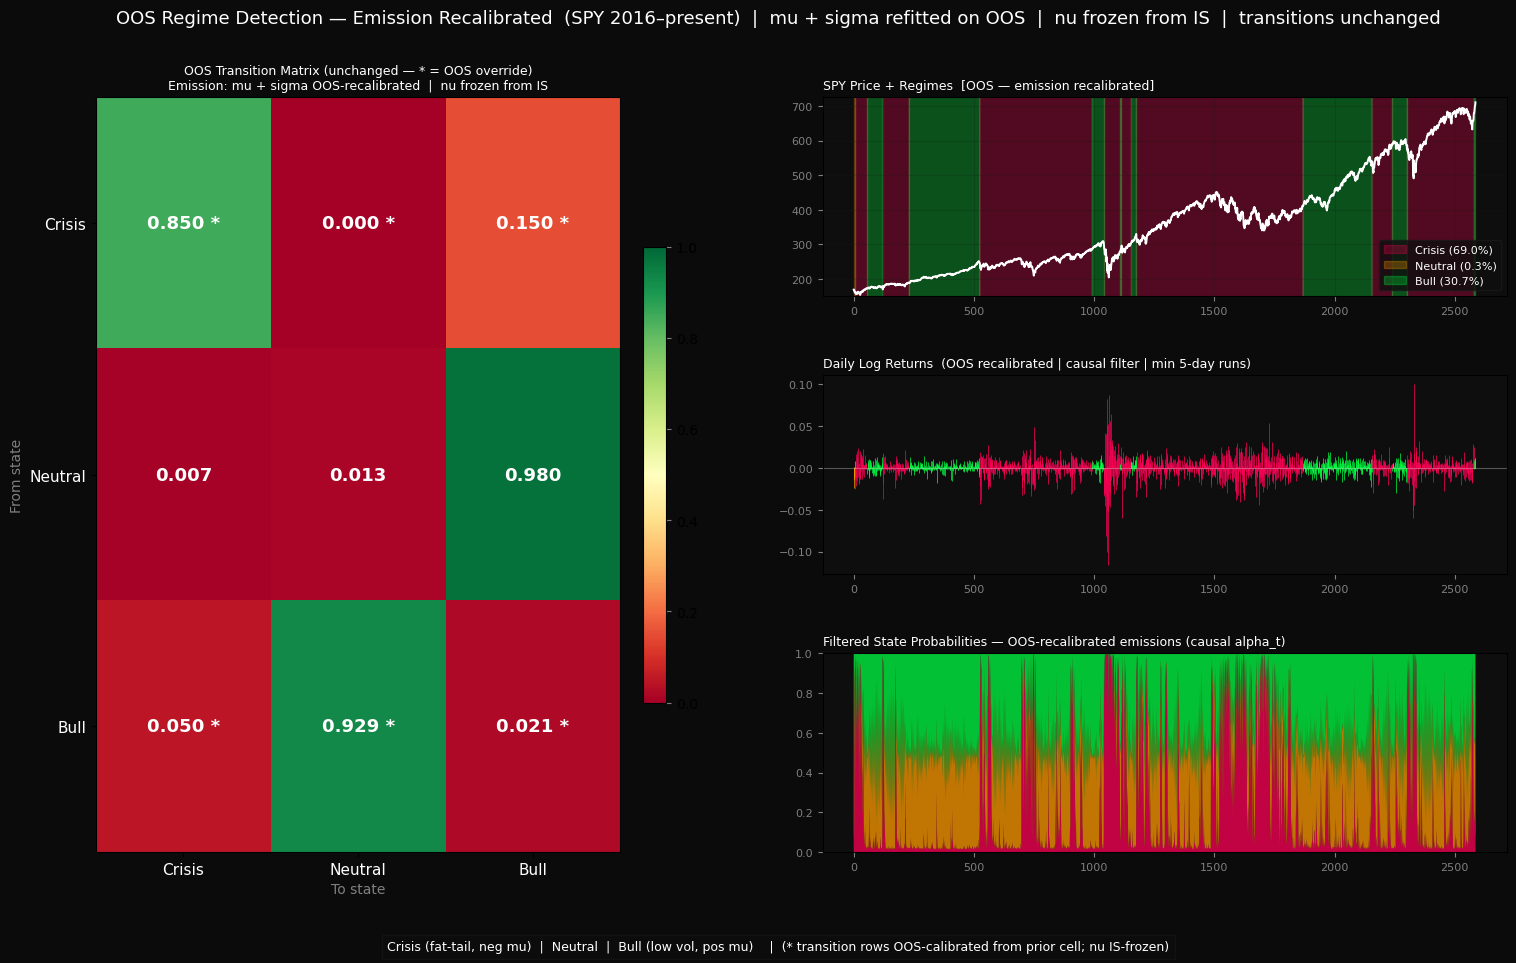

In [13]:
BG, PANEL, GRID = "#0b0b0b", "#0e0e0e", "#1a1a1a"
COLORS = ["#ff0055", "#ff9800", "#00ff41"]

t_oos  = np.arange(len(x_test))
pv_oos = prices_test.values.flatten()

fig = plt.figure(figsize=(18.2, 9.8), dpi=100, facecolor=BG)
gs  = gridspec.GridSpec(3, 2, width_ratios=[1, 1.2], hspace=0.4, wspace=0.25)

# Left col: transition matrix (unchanged — displayed for reference)
ax_tm = fig.add_subplot(gs[:, 0])
ax_tm.set_facecolor(PANEL)
_p_exit = 1.0 - P_CC_OOS
A_disp  = model._transmat(np.array([_z_med])).copy()
A_disp[0] = [P_CC_OOS, _r_n * _p_exit, _r_b * _p_exit]
A_disp[2] = [P_BC_OOS, P_BN_OOS, P_BB_OOS]
im = ax_tm.imshow(A_disp, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for i in range(3):
    for j in range(3):
        txt = f"{A_disp[i,j]:.3f}" + (" *" if i in (0, 2) else "")
        ax_tm.text(j, i, txt, ha="center", va="center",
                   fontsize=13, color="white", fontweight="bold")
ax_tm.set_xticks([0, 1, 2]); ax_tm.set_yticks([0, 1, 2])
ax_tm.set_xticklabels(names, color="white", fontsize=11)
ax_tm.set_yticklabels(names, color="white", fontsize=11)
ax_tm.set_xlabel("To state",   color="gray", fontsize=10)
ax_tm.set_ylabel("From state", color="gray", fontsize=10)
ax_tm.set_title(
    "OOS Transition Matrix (unchanged — * = OOS override)\n"
    "Emission: mu + sigma OOS-recalibrated  |  nu frozen from IS",
    color="white", fontsize=9)
plt.colorbar(im, ax=ax_tm, fraction=0.04, pad=0.04).ax.yaxis.set_tick_params(color="gray")

# Price + recalibrated regime overlay
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor(PANEL)
ax1.plot(t_oos, pv_oos, color="white", linewidth=1.4, zorder=10)
for s in range(3):
    ax1.fill_between(t_oos, pv_oos.min() * 0.95, pv_oos.max() * 1.05,
                     where=(hidden_oos_cal == s), color=COLORS[s],
                     alpha=0.28, step="mid",
                     label=f"{names[s]} ({(hidden_oos_cal==s).mean():.1%})")
ax1.set_ylim(pv_oos.min() * 0.98, pv_oos.max() * 1.02)
ax1.set_title(f"{TICKER} Price + Regimes  [OOS — emission recalibrated]",
              color="white", loc="left", fontsize=9)
ax1.grid(color=GRID, alpha=0.2)
ax1.tick_params(colors="gray", labelsize=8)
leg = ax1.legend(loc="lower right", facecolor=PANEL, edgecolor=GRID, fontsize=8)
[t_.set_color("white") for t_ in leg.get_texts()]

# Returns barcode
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(PANEL)
ax2.vlines(t_oos, 0, x_test,
           color=[COLORS[s] for s in hidden_oos_cal], linewidth=0.5)
ax2.axhline(0, color="white", alpha=0.3, linewidth=0.8)
ax2.set_title("Daily Log Returns  (OOS recalibrated | causal filter | min 5-day runs)",
              color="white", loc="left", fontsize=9)
ax2.tick_params(colors="gray", labelsize=8)

# Recalibrated filtered state probabilities
ax3 = fig.add_subplot(gs[2, 1])
ax3.set_facecolor(PANEL)
ax3.stackplot(t_oos, alpha_cal[:, 0], alpha_cal[:, 1], alpha_cal[:, 2],
              colors=COLORS, alpha=0.75)
ax3.set_ylim(0, 1)
ax3.set_title("Filtered State Probabilities — OOS-recalibrated emissions (causal alpha_t)",
              color="white", loc="left", fontsize=9)
ax3.tick_params(colors="gray", labelsize=8)

plt.suptitle(
    f"OOS Regime Detection — Emission Recalibrated  ({TICKER} 2016–present)  |  "
    "mu + sigma refitted on OOS  |  nu frozen from IS  |  transitions unchanged",
    color="white", fontsize=13, y=0.97)
fig.text(0.5, 0.01,
         "Crisis (fat-tail, neg mu)  |  Neutral  |  Bull (low vol, pos mu)  "
         "  |  (* transition rows OOS-calibrated from prior cell; nu IS-frozen)",
         color="white", ha="center", fontsize=9,
         bbox=dict(facecolor=PANEL, alpha=0.5, edgecolor=GRID))
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()


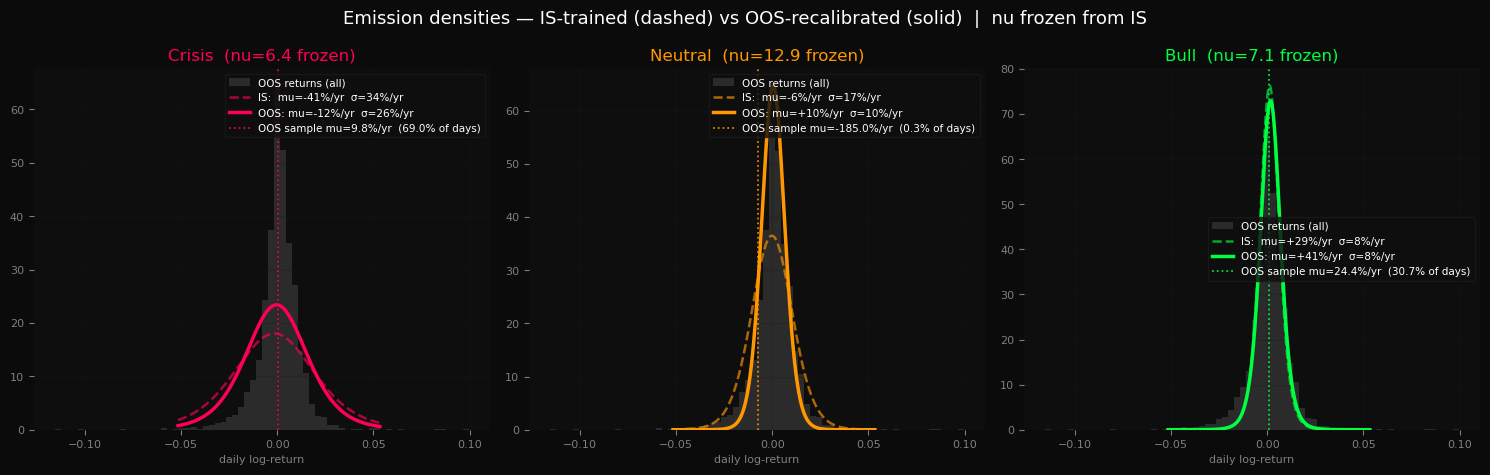

In [14]:
BG, PANEL, GRID = "#0b0b0b", "#0e0e0e", "#1a1a1a"
COLORS = ["#ff0055", "#ff9800", "#00ff41"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), facecolor=BG)
fig.suptitle(
    "Emission densities — IS-trained (dashed) vs OOS-recalibrated (solid)  |  nu frozen from IS",
    color="white", fontsize=13)

q_grid = np.linspace(np.percentile(x_test, 0.2),
                      np.percentile(x_test, 99.8), 600)

for i, (ax, name) in enumerate(zip(axes, names)):
    ax.set_facecolor(PANEL)

    # OOS return histogram (full sample, not state-conditional)
    ax.hist(x_test, bins=70, density=True, color="white", alpha=0.12,
            label="OOS returns (all)")

    # IS-fitted Student-t density (dashed)
    pdf_is = stats.t.pdf(q_grid, df=nu_is[i], loc=mu_is[i], scale=sigma_is[i])
    ax.plot(q_grid, pdf_is, color=COLORS[i], linewidth=1.8, linestyle="--",
            alpha=0.65,
            label=f"IS:  mu={mu_is[i]*252:+.0%}/yr  σ={sigma_is[i]*np.sqrt(252):.0%}/yr")

    # OOS-recalibrated Student-t density (solid, same nu)
    pdf_cal = stats.t.pdf(q_grid, df=nu_is[i], loc=mu_cal[i], scale=sigma_cal[i])
    ax.plot(q_grid, pdf_cal, color=COLORS[i], linewidth=2.5,
            label=f"OOS: mu={mu_cal[i]*252:+.0%}/yr  σ={sigma_cal[i]*np.sqrt(252):.0%}/yr")

    # Vertical line at OOS sample mean for this (recalibrated) regime
    mask = hidden_oos_cal == i
    if mask.any():
        ax.axvline(x_test[mask].mean(), color=COLORS[i],
                   linestyle=":", linewidth=1.3, alpha=0.85,
                   label=f"OOS sample mu={x_test[mask].mean()*252:.1%}/yr  "
                         f"({mask.mean():.1%} of days)")

    ax.set_title(f"{name}  (nu={nu_is[i]:.1f} frozen)",
                 color=COLORS[i], fontsize=12)
    ax.set_xlabel("daily log-return", color="gray", fontsize=8)
    ax.tick_params(colors="gray", labelsize=8)
    ax.grid(color=GRID, alpha=0.3)
    for sp in ax.spines.values():
        sp.set_visible(False)
    leg = ax.legend(facecolor=PANEL, edgecolor=GRID, fontsize=7.5)
    [t_.set_color("white") for t_ in leg.get_texts()]

plt.tight_layout()
plt.show()


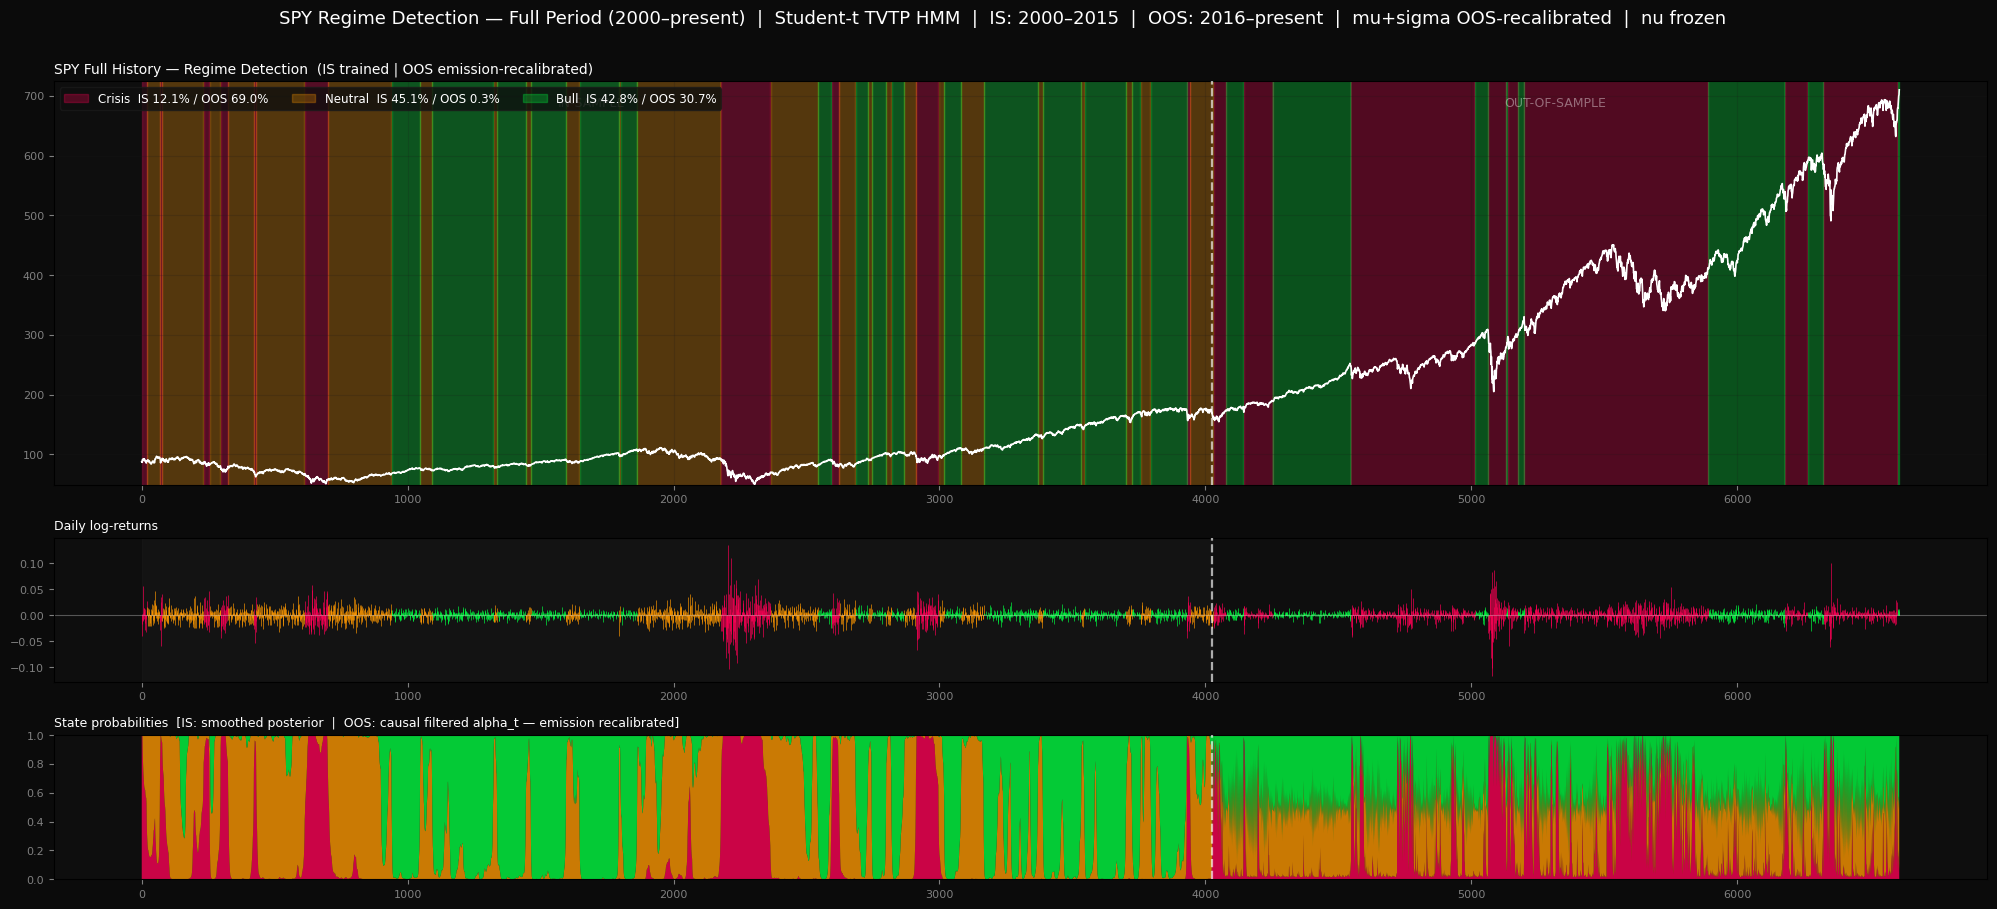

In [15]:
BG, PANEL, GRID = "#0b0b0b", "#0e0e0e", "#1a1a1a"
COLORS = ["#ff0055", "#ff9800", "#00ff41"]

all_states    = np.concatenate([hidden_states_train, hidden_oos_cal])
all_x         = np.concatenate([x_train, x_test])
all_pv        = np.concatenate([prices_train.values.flatten(),
                                 prices_test.values.flatten()])
combined_post = np.vstack([posterior_train, alpha_cal])
cutoff_idx    = int(train_mask.sum())
tt            = np.arange(len(all_x))

fig, axes = plt.subplots(3, 1, figsize=(20, 9), facecolor=BG,
                         gridspec_kw={"height_ratios": [2.8, 1, 1]})
for ax in axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors="gray", labelsize=8)
    ax.axvspan(0, cutoff_idx, color="white", alpha=0.025)
    ax.axvline(cutoff_idx, color="white", linewidth=1.6,
               linestyle="--", alpha=0.65, zorder=20)

ax = axes[0]
ax.plot(tt, all_pv, color="white", linewidth=1.2, zorder=10)
for s in range(3):
    is_f  = (hidden_states_train == s).mean()
    oos_f = (hidden_oos_cal      == s).mean()
    ax.fill_between(tt, all_pv.min() * 0.95, all_pv.max() * 1.05,
                    where=(all_states == s), color=COLORS[s], alpha=0.28,
                    step="mid",
                    label=f"{names[s]}  IS {is_f:.1%} / OOS {oos_f:.1%}")
ax.set_ylim(all_pv.min() * 0.98, all_pv.max() * 1.02)
ax.text(cutoff_idx * 0.42, all_pv.max() * 0.96,
        "IN-SAMPLE", color="white", alpha=0.40, fontsize=9, ha="center")
ax.text(cutoff_idx + (len(all_x) - cutoff_idx) * 0.5, all_pv.max() * 0.96,
        "OUT-OF-SAMPLE", color="white", alpha=0.40, fontsize=9, ha="center")
ax.set_title(f"{TICKER} Full History — Regime Detection  (IS trained | OOS emission-recalibrated)",
             color="white", loc="left", fontsize=10)
ax.grid(color=GRID, alpha=0.18)
leg = ax.legend(loc="upper left", facecolor=PANEL, edgecolor=GRID,
                fontsize=8.5, ncol=3)
[t_.set_color("white") for t_ in leg.get_texts()]

ax = axes[1]
ax.vlines(tt, 0, all_x,
          color=[COLORS[s] for s in all_states], linewidth=0.45)
ax.axhline(0, color="white", alpha=0.3, linewidth=0.8)
ax.set_title("Daily log-returns", color="white", loc="left", fontsize=9)

ax = axes[2]
ax.stackplot(tt,
             combined_post[:, 0], combined_post[:, 1], combined_post[:, 2],
             colors=COLORS, alpha=0.78)
ax.set_ylim(0, 1)
ax.set_title(
    "State probabilities  "
    "[IS: smoothed posterior  |  OOS: causal filtered alpha_t — emission recalibrated]",
    color="white", loc="left", fontsize=9)

plt.suptitle(
    f"{TICKER} Regime Detection — Full Period ({START[:4]}–present)  |  "
    f"Student-t TVTP HMM  |  IS: {START[:4]}–{TRAIN_END[:4]}  |  "
    f"OOS: 2016–present  |  mu+sigma OOS-recalibrated  |  nu frozen",
    color="white", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()


In [16]:
# ── Regime-conditional statistics — OUT-OF-SAMPLE ────────────────────────────
# Sharpe ratio, max drawdown, and hit rate for each recalibrated OOS regime.
# Hit rate: % of regime days where the NEXT day's return has the regime-consistent
# directional sign  (Crisis → negative, Bull → positive, Neutral → not defined).

TRADING_DAYS = 252

print("=" * 84)
print("  OOS Regime-Conditional Statistics  (2016–present | emission-recalibrated)")
print("=" * 84)
print(f"  {'State':8s}  {'Days':>5s}  {'%Time':>6s}  {'Ann.Ret':>8s}  "
      f"{'Ann.Vol':>8s}  {'Sharpe':>7s}  {'MaxDD':>8s}  {'HitRate':>9s}")
print("-" * 84)

for i, name in enumerate(names):
    mask = hidden_oos_cal == i
    r    = x_test[mask]
    n    = mask.sum()

    if n < 5:
        print(f"  {name:8s}  {n:>5d}  — insufficient data —")
        continue

    # Annualised return and vol (log-return basis)
    mu_ann  = r.mean() * TRADING_DAYS
    sig_ann = r.std()  * np.sqrt(TRADING_DAYS)
    sharpe  = mu_ann / sig_ann if sig_ann > 1e-10 else np.nan

    # Max drawdown on regime days only (wealth index over regime sub-series)
    wealth  = np.cumprod(1.0 + r)
    peak    = np.maximum.accumulate(wealth)
    max_dd  = ((wealth - peak) / peak).min()

    # Hit rate: directional accuracy of next-day return
    idx      = np.where(mask)[0]
    idx_next = idx[idx < len(x_test) - 1]   # drop last obs (no next day)
    if len(idx_next) > 10:
        next_r = x_test[idx_next + 1]
        if i == 0:   # Crisis: expect negative next day
            hit = (next_r < 0).mean()
        elif i == 2: # Bull:   expect positive next day
            hit = (next_r > 0).mean()
        else:        # Neutral: no directional expectation
            hit = np.nan
    else:
        hit = np.nan

    hr_str = f"{hit:.1%}" if not np.isnan(hit) else "   —   "
    print(f"  {name:8s}  {n:>5d}  {mask.mean():>5.1%}  "
          f"{mu_ann:>+7.1%}  {sig_ann:>7.1%}  "
          f"{sharpe:>+6.2f}  {max_dd:>7.1%}  {hr_str:>9s}")

print("=" * 84)
print()
print("  Sharpe  : annualised log-return / annualised vol  (rf = 0)")
print("  Max DD  : computed over regime-day sub-series only")
print("  Hit Rate: % of regime days where next-day return has regime-consistent sign")
print("            (Crisis → neg next day | Bull → pos next day | Neutral → n/a)")


  OOS Regime-Conditional Statistics  (2016–present | emission-recalibrated)
  State      Days   %Time   Ann.Ret   Ann.Vol   Sharpe     MaxDD    HitRate
------------------------------------------------------------------------------------
  Crisis     1786  69.0%    +9.8%    20.5%   +0.48   -35.1%      45.9%
  Neutral       7   0.3%  -185.0%    16.6%  -11.17    -4.7%       —   
  Bull        794  30.7%   +24.4%     9.8%   +2.49   -10.1%      58.9%

  Sharpe  : annualised log-return / annualised vol  (rf = 0)
  Max DD  : computed over regime-day sub-series only
  Hit Rate: % of regime days where next-day return has regime-consistent sign
            (Crisis → neg next day | Bull → pos next day | Neutral → n/a)
